# Chapter 15 Exercise Questions
Topic covering the RDKit package

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, PandasTools
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import rdFingerprintGenerator

from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))

### Question 1

Load the structure for morphine into RDKit using either a SMILES or InChI representation. You will need to either generate one of these representations using chemical drawing software or find one online from a free resource.

a) Visualize the structure of morphine and save it as an SVG image file.

b) Use RDKit to determine the number of chiral centers in the structure. Your code should output an integer value, not just a list of chiral centers.

c) Use RDKit to determine the number of hydrogen bond acceptors in the structure.

d) Use RDKit to determine the number of rings in the structure.

In [3]:
morphine_smiles = ('CN1CC[C@]23c4c5ccc(O)c4O[C@H]2[C@@H](O)C=C[C@H]3[C@H]1C5')

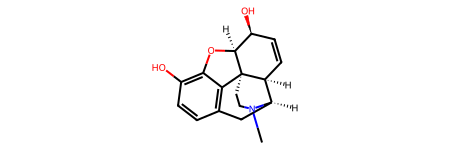

In [5]:
morphine = Chem.MolFromSmiles(morphine_smiles)
morphine

In [8]:
Chem.Draw.MolToFile(morphine, 'data/morphine.SVG',
                   size=(500,500),
                   imageType='svg')

In [24]:
len(Chem.FindMolChiralCenters(morphine))

5

In [25]:
Chem.Descriptors.NumHAcceptors(morphine)

4

In [27]:
Chem.Descriptors.RingCount(morphine)

5

### Question 2

Load the `amino_acid_SMILES.txt` file and use RDKit for the following.

a) Determine the absolute configuration (i.e., R vs. S) of the $\alpha$-carbon for all the chiral amino acids. Most are the same, but one is an exception. Which is it?

b) How many amino acids have two chiral centers?

In [46]:
df = pd.read_csv('data/amino_acid_SMILES.txt', skiprows=2)
AminoAcids = [Chem.MolFromSmiles(SMILES) for SMILES in df['SMILES']]
df

,name,SMILES
0,alanine,C[C@@H](C(=O)[O-])[NH3+]
1,arginine,[NH3+][C@@H](CCCNC(=[NH2+])N)C(=O)[O-]
2,asparagine,O=C(N)C[C@H]([NH3+])C(=O)[O-]
3,aspartate,C([C@@H](C(=O)[O-])[NH3+])C(=O)[O-]
4,cysteine,C([C@@H](C(=O)[O-])[NH3+])S
5,glutamine,[NH3+][C@@H](CCC(=O)N)C([O-])=O
6,glutamate,C(CC(=O)[O-])[C@@H](C(=O)[O-])[NH3+]
7,glycine,C(C(=O)[O-])[NH3+]
8,histidine,O=C([C@H](CC1=CNC=N1)[NH3+])[O-]
9,isoleucine,CC[C@H](C)[C@@H](C(=O)[O-])[NH3+]


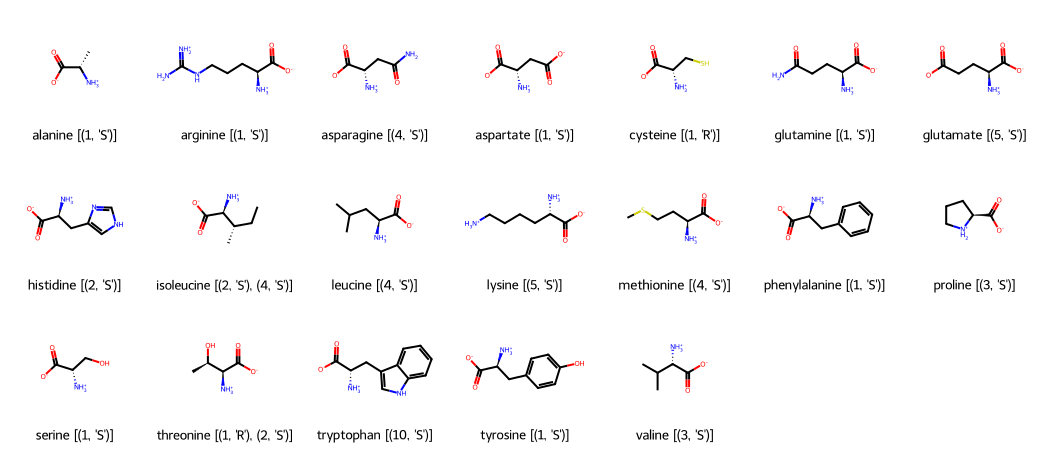

In [69]:
chiral_df = df.copy()
chiral_df['chiral_centers'] = [Chem.FindMolChiralCenters(mol) for mol in AminoAcids]
chiral_df = chiral_df.drop(chiral_df[chiral_df['chiral_centers'].apply(len) == 0].index).reset_index(drop=True)

Chem.Draw.MolsToGridImage([Chem.MolFromSmiles(SMILES) for SMILES in chiral_df['SMILES']], 
                          molsPerRow=7,
                          subImgSize=(150,150),
                          legends=[f"{row['name']} {row['chiral_centers']}" for _, row in chiral_df.iterrows()],
                          useSVG=True)    



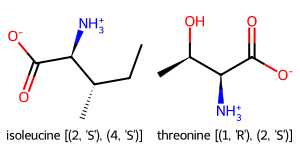

In [71]:
twochiral = chiral_df[chiral_df['chiral_centers'].apply(len) == 2]
Chem.Draw.MolsToGridImage([Chem.MolFromSmiles(SMILES) for SMILES in twochiral['SMILES']], 
                          molsPerRow=2,
                          subImgSize=(150,150),
                          legends=[f"{row['name']} {row['chiral_centers']}" for _, row in twochiral.iterrows()],
                          useSVG=True)   

This code identifies the absolute configuration (R or S) of the alpha carbon for each chiral amino acid.

- `MolFromSmarts` defines a SMARTS pattern matching the alpha carbon environment — an amine, a chiral carbon, a side chain (`*`), and a carboxyl group.
- `GetSubstructMatch` returns the atom indices where that pattern matches in the molecule. `match[1]` is always the alpha carbon as it is the second atom in the SMARTS pattern.
- `chiral_centers` is a list of `(atom_index, configuration)` tuples. The list comprehension filters for the tuple matching the alpha carbon index and extracts the R/S label.

In [79]:
alpha_smarts = Chem.MolFromSmarts('[NH2,NH3+][C@@H,C@H](*)C(=O)[O-,OH]')

for _, row in twochiral.iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    match = mol.GetSubstructMatch(alpha_smarts)
    alpha_idx = match[1]
    alpha_config = [config for idx, config in row['chiral_centers'] if idx == alpha_idx][0]
    print(f"{row['name']}: {alpha_config}")


isoleucine: S
threonine: S
